# 🏷 Notebook 2: Classification Comparison — CNN vs RNN vs Transformer
Train 3 custom classifiers on 80×80 labeled RBC images (9 classes).
**Metrics:** Accuracy, Macro F1, Confusion Matrix

In [1]:
# !pip install -q scikit-learn matplotlib seaborn tqdm pillow


In [2]:
import os, random, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torchvision import transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
torch.manual_seed(42)


Device: cpu


In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
DATASET_BASE = r"c:\Users\DELL\Desktop\Vinh Hoang\Master Program\Học sâu\Project\Dataset"
# from google.colab import drive; drive.mount('/content/drive')
# DATASET_BASE = "/content/drive/MyDrive/Project/Dataset"

CLS_DIR       = os.path.join(DATASET_BASE, "Elsafty_RBCs_for_Classification", "Cropped images")
IMG_SIZE      = 80
BATCH_SIZE    = 64
EPOCHS        = 50
LR            = 1e-3
SAMPLES_PER_CLASS = 1500   # set lower (e.g. 800) if RAM is limited

RESULTS_DIR = os.path.join(os.path.dirname(DATASET_BASE), "results", "classification")
os.makedirs(RESULTS_DIR, exist_ok=True)
print("Config OK")


Config OK


In [4]:
# ── Dataset ───────────────────────────────────────────────────────────────────
import zipfile
cls_dir_path = Path(CLS_DIR)
import zipfile, shutil
cls_dir_path = Path(CLS_DIR)
# 1. Tự động giải nén tất cả các file zip nếu có
for z in cls_dir_path.glob("*.zip"):
    print(f"Bung file nén: {z.name} ...")
    with zipfile.ZipFile(z, 'r') as zf:
        zf.extractall(cls_dir_path)

# 2. Dọn dẹp: Xóa các thư mục rỗng hoặc không chứa ảnh (thường do zip tạo ra thư mục thừa)
for d in list(cls_dir_path.iterdir()):
    if d.is_dir() and not d.name.startswith('.'):
        has_png = any(d.rglob("*.png"))
        if not has_png:
            print(f"🗑️ Đang xóa thư mục rỗng/thừa: {d.name}")
            shutil.rmtree(d)

# 3. CHỈ lấy những thư mục thực sự chứa ảnh .png và chuẩn hóa danh sách class
CLASSES = sorted([d.name for d in cls_dir_path.iterdir() if d.is_dir() and any(d.glob("*.png"))])
print(f"Classes ({len(CLASSES)}): {CLASSES}")
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}

class RBCClsDataset(Dataset):
    def __init__(self, samples, augment=False):
        self.samples = samples
        base = [transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(),
                transforms.Normalize([0.5]*3, [0.5]*3)]
        aug  = [transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
                transforms.RandomRotation(15)]
        self.tf = transforms.Compose((aug if augment else []) + base)

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return self.tf(Image.open(path).convert("RGB")), label


def load_samples(cls_dir, spc, classes):
    samples = []
    for cls in classes:
        folder = Path(cls_dir) / cls
        files  = sorted(folder.glob("*.png"))
        if len(files) == 0:
             print(f"⚠ Lỗi: Thư mục {cls} không có ảnh .png nào!")
             continue
        chosen = random.sample(list(files), min(spc, len(files)))
        for f in chosen:
            samples.append((str(f), CLASS2IDX[cls]))
    random.shuffle(samples)
    if len(samples) == 0:
        raise ValueError("Data rỗng! Không collect được ảnh nào cho Classification.")
    return samples

all_samples = load_samples(CLS_DIR, SAMPLES_PER_CLASS, CLASSES)
print(f"Total samples: {len(all_samples)}")

n_train = int(0.7 * len(all_samples))
n_val   = int(0.15 * len(all_samples))
n_test  = len(all_samples) - n_train - n_val

train_s, val_s, test_s = (all_samples[:n_train],
                           all_samples[n_train:n_train+n_val],
                           all_samples[n_train+n_val:])

train_ds = RBCClsDataset(train_s, augment=True)
val_ds   = RBCClsDataset(val_s)
test_ds  = RBCClsDataset(test_s)

# Tính toán sample_weights dựa trên phân phối class thực tế của tập train
from collections import Counter
train_labels = [label for _, label in train_s]
class_counts = Counter(train_labels)
class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = [class_weights[label] for label in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_dl = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=(DEVICE=="cuda"))
val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(DEVICE=="cuda"))
test_dl  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(DEVICE=="cuda"))
print(f"Train/Val/Test: {n_train}/{n_val}/{n_test}")


Bung file nén: CROPPED - Class 1 - Rounded RBCs.zip ...
Bung file nén: CROPPED - Class 2 - Ovalocytes.zip ...
Bung file nén: CROPPED - Class 3 - Fragmented RBCs.zip ...
Bung file nén: CROPPED - Class 4 - Two Overlapping RBCs.zip ...
Bung file nén: CROPPED - Class 5 - Three Overlapping RBCs.zip ...
Bung file nén: CROPPED - Class 6 - Burr Cells.zip ...
Bung file nén: CROPPED - Class 7 - Teardrops.zip ...
Bung file nén: CROPPED - Class 8 - Angled Cells.zip ...
Bung file nén: CROPPED - Class 9 - Borderline Ovalocytes.zip ...
Classes (9): ['CROPPED - Class 1 - Rounded RBCs', 'CROPPED - Class 2 - Ovalocytes', 'CROPPED - Class 3 - Fragmented RBCs', 'CROPPED - Class 4 - Two Overlapping RBCs', 'CROPPED - Class 5 - Three Overlapping RBCs', 'CROPPED - Class 6 - Burr Cells', 'CROPPED - Class 7 - Teardrops', 'CROPPED - Class 8 - Angled Cells', 'CROPPED - Class 9 - Borderline Ovalocytes']
Total samples: 13500
Train/Val/Test: 9450/2025/2025


## 🏗 Model Architectures
### Pipeline A — Custom CNN Classifier

In [5]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.ca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, max(1, channels // reduction), 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(max(1, channels // reduction), channels, 1, bias=False),
            nn.Sigmoid()
        )
        self.sa = nn.Sequential(nn.Conv2d(2, 1, 7, padding=3, bias=False), nn.Sigmoid())
    def forward(self, x):
        x = x * self.ca(x); max_o, _ = torch.max(x, dim=1, keepdim=True); avg_o = torch.mean(x, dim=1, keepdim=True)
        return x * self.sa(torch.cat([max_o, avg_o], dim=1))

class CNNClassifier(nn.Module):
    def __init__(self, n_classes=9):
        super().__init__()
        self.layer1 = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.cbam1  = CBAM(32)
        self.layer2 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.cbam2  = CBAM(64)
        self.layer3 = nn.Sequential(nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128),nn.ReLU(), nn.MaxPool2d(2))
        self.cbam3  = CBAM(128)
        self.layer4 = nn.Sequential(nn.Conv2d(128,256,3, padding=1), nn.BatchNorm2d(256),nn.ReLU(), nn.AdaptiveAvgPool2d(1))
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.4), nn.Linear(256, n_classes))

    def forward(self, x):
        x = self.cbam1(self.layer1(x))
        x = self.cbam2(self.layer2(x))
        x = self.cbam3(self.layer3(x))
        x = self.layer4(x)
        return self.head(x)

model_cnn = CNNClassifier(n_classes=len(CLASSES)).to(DEVICE)
print(f"CNN params: {sum(p.numel() for p in model_cnn.parameters()):,}")


CNN params: 394,671


### Pipeline B — Custom RNN (BiGRU) Classifier

In [6]:
class BiGRUClassifier(nn.Module):
    """Treat each row of the 80×80 image as a time step (seq_len=80, input=80*3=240)."""
    def __init__(self, n_classes=9, hidden=128, n_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(IMG_SIZE * 3, hidden)
        self.gru = nn.GRU(hidden, hidden, n_layers, batch_first=True,
                          bidirectional=True, dropout=0.3)
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, n_classes))

    def forward(self, x):
        B, C, H, W = x.shape
        x = x.permute(0, 2, 3, 1).reshape(B, H, W * C)  # B, H, W*C
        x = self.input_proj(x)                            # B, H, hidden
        out, _ = self.gru(x)                              # B, H, hidden*2
        return self.head(out[:, -1, :])                   # last timestep

model_rnn = BiGRUClassifier(n_classes=len(CLASSES)).to(DEVICE)
print(f"BiGRU params: {sum(p.numel() for p in model_rnn.parameters()):,}")


BiGRU params: 559,497


### Pipeline C — Custom Vision Transformer (ViT) Classifier

In [7]:
class TransBlock(nn.Module):
    def __init__(self, dim=128, heads=4, mlp_ratio=3, drop=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, dropout=drop, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, dim*mlp_ratio), nn.GELU(), nn.Dropout(drop),
            nn.Linear(dim*mlp_ratio, dim), nn.Dropout(drop))
    def forward(self, x):
        n = self.norm1(x); x = x + self.attn(n,n,n)[0]
        return x + self.mlp(self.norm2(x))

class ViTClassifier(nn.Module):
    def __init__(self, img_size=80, patch_size=8, in_ch=3, n_classes=9,
                 embed_dim=128, depth=4, heads=4):
        super().__init__()
        n_patches = (img_size // patch_size) ** 2
        self.patch_proj = nn.Conv2d(in_ch, embed_dim, patch_size, patch_size)
        self.cls_token  = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        self.pos_embed  = nn.Parameter(torch.randn(1, n_patches + 1, embed_dim) * 0.02)
        self.blocks     = nn.Sequential(*[TransBlock(embed_dim, heads) for _ in range(depth)])
        self.norm       = nn.LayerNorm(embed_dim)
        self.head       = nn.Linear(embed_dim, n_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_proj(x).flatten(2).transpose(1,2)   # B, N, E
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1) + self.pos_embed  # B, N+1, E
        x   = self.norm(self.blocks(x))
        return self.head(x[:, 0])                           # CLS token

model_vit = ViTClassifier(n_classes=len(CLASSES)).to(DEVICE)
print(f"ViT params:  {sum(p.numel() for p in model_vit.parameters()):,}")


ViT params:  700,681


## 🏋 Training

In [8]:
def train_cls(model, name, epochs=EPOCHS, lr=LR):
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    # Dùng ReduceLROnPlateau thay cho Cosine để adaptive hơn với Early Stopping
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', patience=3, factor=0.5)
    # Kỹ thuật: Label Smoothing (0.1) giúp model chống overfitting và tự tin thái quá
    crit  = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    early_stop_patience = 10
    min_delta = 0.003
    epochs_no_improve = 0

    best_acc, best_state = 0., None
    history = {"train_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.
        for imgs, labels in train_dl:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(imgs), labels)
            loss.backward()
            # Gradient Clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            running += loss.item()

        model.eval(); correct = total = 0
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                preds = model(imgs).argmax(1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        acc = correct / total
        sched.step(acc)

        history["train_loss"].append(running / len(train_dl))
        history["val_acc"].append(acc)

        if acc > best_acc + min_delta:
            best_acc  = acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if True:  # Log every epoch as requested
            curr_lr = opt.param_groups[0]['lr']
            print(f"[{name}] Epoch {epoch:3d}/{epochs} | LR {curr_lr:.1e} | "
                  f"Loss {running/len(train_dl):.4f} | Val Acc {acc:.4f}")
                  
        if epochs_no_improve >= early_stop_patience:
            print(f"🛑 Early stopping tại epoch {epoch} (Không cải thiện sau {early_stop_patience} epochs)")
            break

    model.load_state_dict(best_state)
    torch.save(best_state, f"{RESULTS_DIR}/{name}_best.pt")
    print(f"✅ {name} best Val Acc = {best_acc:.4f}")
    return history


In [9]:
t0=time.time(); hist_cnn = train_cls(model_cnn, "CNN_Cls")
print(f"⏱ {(time.time()-t0)/60:.1f} min\n")
t0=time.time(); hist_rnn = train_cls(model_rnn, "RNN_Cls")
print(f"⏱ {(time.time()-t0)/60:.1f} min\n")
t0=time.time(); hist_vit = train_cls(model_vit, "ViT_Cls")
print(f"⏱ {(time.time()-t0)/60:.1f} min")


[CNN_Cls] Epoch   1/50 | LR 1.0e-03 | Loss 1.8469 | Val Acc 0.4523
[CNN_Cls] Epoch   2/50 | LR 1.0e-03 | Loss 1.5096 | Val Acc 0.5886
[CNN_Cls] Epoch   3/50 | LR 1.0e-03 | Loss 1.3300 | Val Acc 0.5299
[CNN_Cls] Epoch   4/50 | LR 1.0e-03 | Loss 1.2088 | Val Acc 0.6686
[CNN_Cls] Epoch   5/50 | LR 1.0e-03 | Loss 1.1193 | Val Acc 0.6341
[CNN_Cls] Epoch   6/50 | LR 1.0e-03 | Loss 1.0758 | Val Acc 0.7062
[CNN_Cls] Epoch   7/50 | LR 1.0e-03 | Loss 1.0329 | Val Acc 0.7264
[CNN_Cls] Epoch   8/50 | LR 1.0e-03 | Loss 1.0092 | Val Acc 0.7644
[CNN_Cls] Epoch   9/50 | LR 1.0e-03 | Loss 0.9980 | Val Acc 0.7951
[CNN_Cls] Epoch  10/50 | LR 1.0e-03 | Loss 0.9724 | Val Acc 0.7832
[CNN_Cls] Epoch  11/50 | LR 1.0e-03 | Loss 0.9578 | Val Acc 0.7931
[CNN_Cls] Epoch  12/50 | LR 1.0e-03 | Loss 0.9411 | Val Acc 0.7802
[CNN_Cls] Epoch  13/50 | LR 5.0e-04 | Loss 0.9323 | Val Acc 0.7852
[CNN_Cls] Epoch  14/50 | LR 5.0e-04 | Loss 0.8974 | Val Acc 0.8400
[CNN_Cls] Epoch  15/50 | LR 5.0e-04 | Loss 0.8742 | Val Acc 0.

## 📊 Evaluation

In [10]:
def evaluate_cls(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            preds = model(imgs.to(DEVICE)).argmax(1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

results_cls = {}
for m, name in [(model_cnn,"CNN"), (model_rnn,"RNN"), (model_vit,"ViT")]:
    preds, labels = evaluate_cls(m, test_dl)
    report = classification_report(labels, preds, target_names=CLASSES, output_dict=True)
    results_cls[name] = {
        "Accuracy": report["accuracy"],
        "Macro F1": report["macro avg"]["f1-score"],
        "preds": preds, "labels": labels,
    }
    print(f"\n{'='*50}")
    print(f"  {name} — Accuracy: {report['accuracy']:.4f}  Macro F1: {report['macro avg']['f1-score']:.4f}")
    print(classification_report(labels, preds, target_names=CLASSES))



  CNN — Accuracy: 0.8904  Macro F1: 0.8886
                                            precision    recall  f1-score   support

          CROPPED - Class 1 - Rounded RBCs       0.85      0.96      0.90       221
            CROPPED - Class 2 - Ovalocytes       0.89      0.87      0.88       225
       CROPPED - Class 3 - Fragmented RBCs       0.94      1.00      0.97       214
  CROPPED - Class 4 - Two Overlapping RBCs       0.85      0.91      0.88       219
CROPPED - Class 5 - Three Overlapping RBCs       0.93      0.90      0.91       227
            CROPPED - Class 6 - Burr Cells       0.96      0.95      0.96       221
             CROPPED - Class 7 - Teardrops       0.91      0.94      0.93       249
          CROPPED - Class 8 - Angled Cells       0.83      0.67      0.74       227
 CROPPED - Class 9 - Borderline Ovalocytes       0.84      0.82      0.83       222

                                  accuracy                           0.89      2025
                              

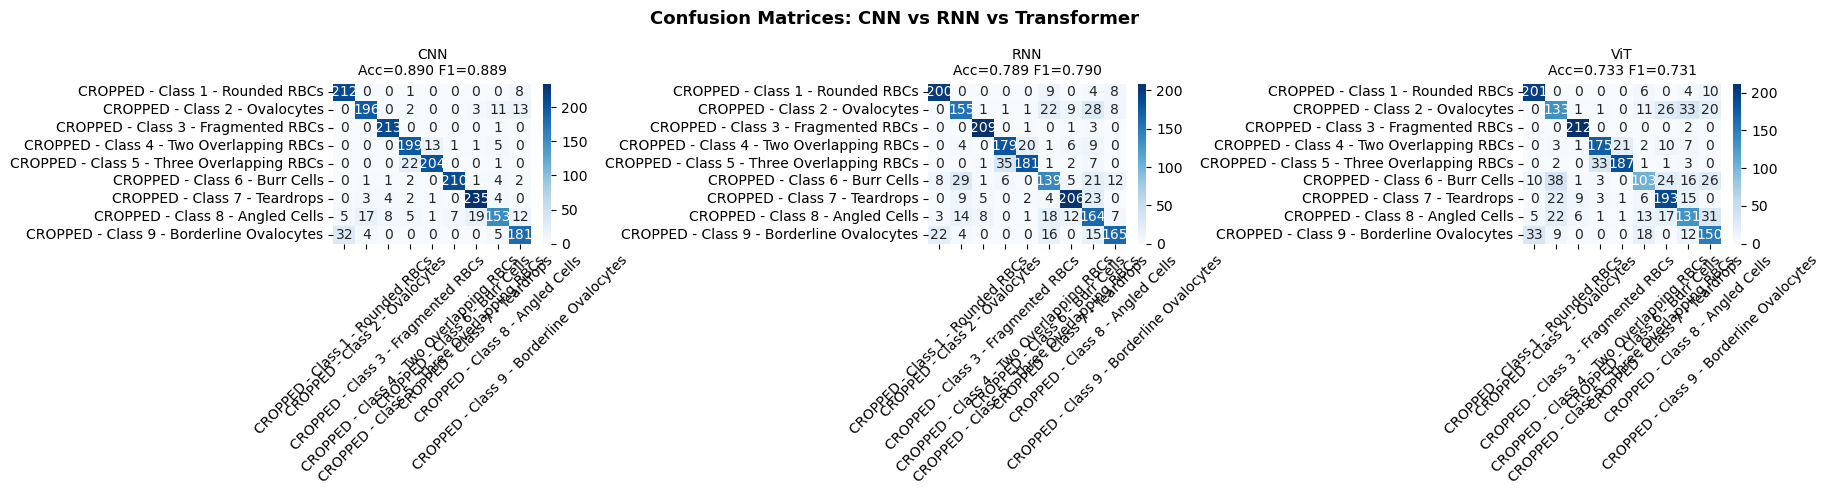

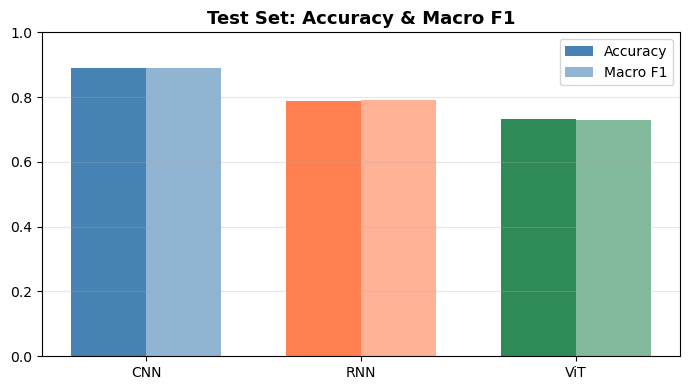

In [11]:
# Confusion matrices & comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, r) in zip(axes, results_cls.items()):
    cm = confusion_matrix(r["labels"], r["preds"])
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES)
    ax.set_title(f"{name}\nAcc={r['Accuracy']:.3f} F1={r['Macro F1']:.3f}", fontsize=10)
    ax.tick_params(axis='x', rotation=45)
plt.suptitle("Confusion Matrices: CNN vs RNN vs Transformer", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrices.png", dpi=150)
plt.show()

names  = list(results_cls.keys())
accs   = [results_cls[n]["Accuracy"] for n in names]
f1s    = [results_cls[n]["Macro F1"] for n in names]
fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(names)); w = 0.35
ax.bar(x-w/2, accs, w, label="Accuracy", color=["steelblue","coral","seagreen"])
ax.bar(x+w/2, f1s,  w, label="Macro F1", color=["steelblue","coral","seagreen"], alpha=0.6)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0,1); ax.legend(); ax.grid(axis="y", alpha=0.3)
ax.set_title("Test Set: Accuracy & Macro F1", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/accuracy_comparison.png", dpi=150)
plt.show()
